# JOBSHEET 5 - MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA

Nama: Tsabitah Hilyatul Aulia  
NIM: 3.34.23.3.23  
Kelas: IK-3D  
Mata Kuliah: Pengolahan Citra  

## P1 - Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


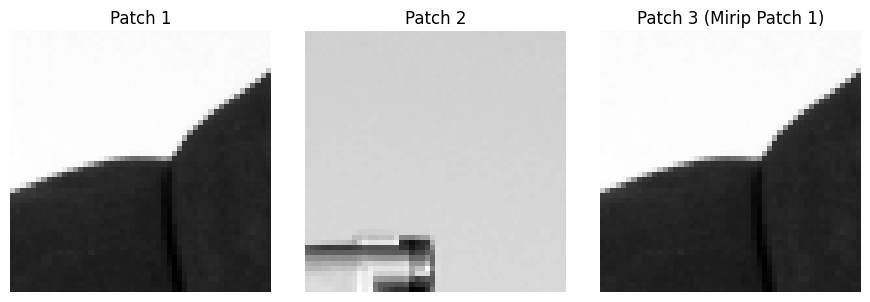

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## P2 - Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


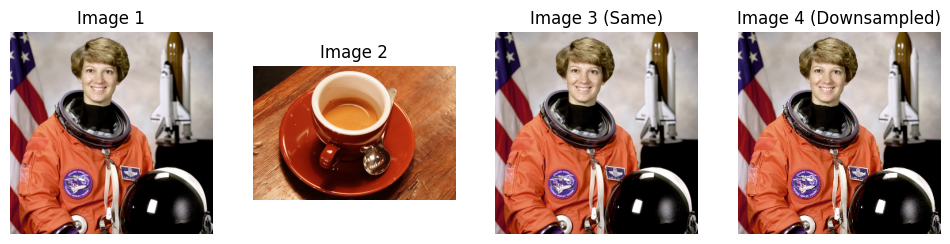

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(
        img_uint8[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        img_uint8[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        img_uint8[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined


# Muat dua citra berwarna
try:
    # Gunakan citra berbeda dari skimage atau file Anda
    image1 = data.astronaut()
    image2 = data.coffee()  # Citra yang berbeda
    image3 = data.astronaut()  # Citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :]  # Versi downsampled dari image1

except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")

    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]


# Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)


# Hitung Cosine Similarity (1 - Cosine Distance)
# scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)


# Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")


# Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.show()

## P3 - Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2965
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


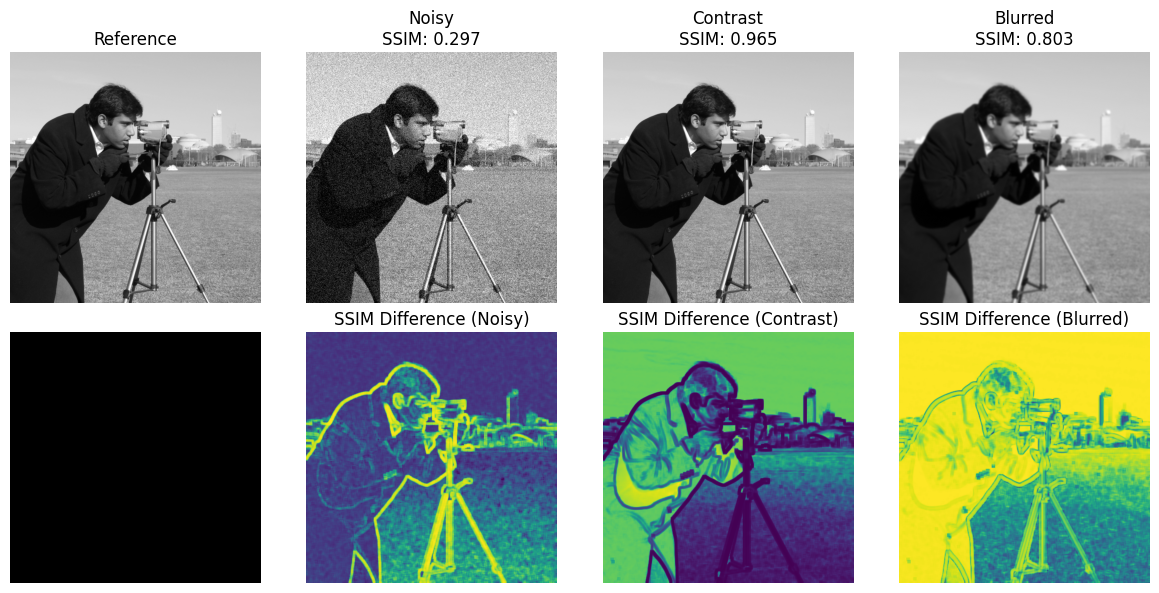

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian


# Muat citra referensi
image_ref = img_as_float(data.camera())


# Buat beberapa versi citra yang 'terdistorsi'

# Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()

# Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

# Citra dengan kontras berbeda
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# Citra yang di-blur
image_blurred = gaussian(
    image_ref,
    sigma=1.5,
    channel_axis=None
)  # channel_axis=None jika grayscale


# Hitung SSIM antara citra referensi dan citra terdistorsi

# SSIM memerlukan data_range
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)

# 'full=True' mengembalikan citra perbedaan SSIM juga


# Tampilkan hasil SSIM dan citra perbedaan
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()


ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')


# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('')
ax[4].axis('off')  # Placeholder

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')


plt.tight_layout()
plt.show()

## P4 - Penerapan Template Matching

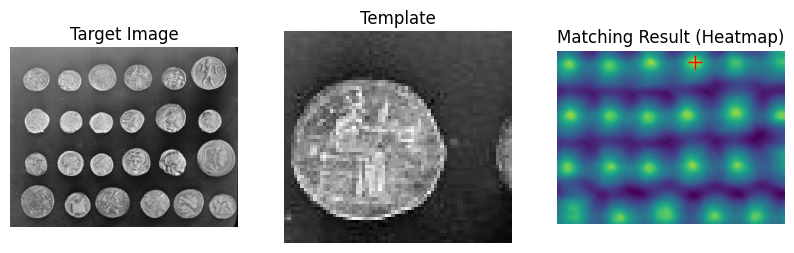

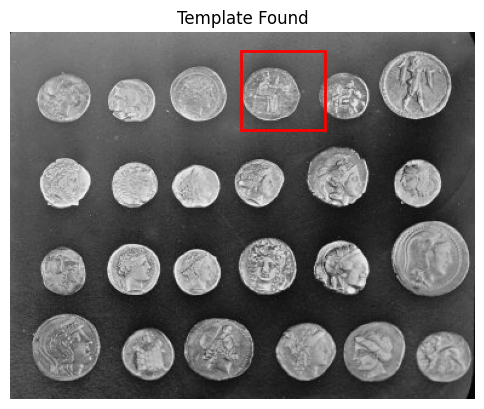

Template ditemukan di koordinat (x,y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template


# Muat citra target dan buat/muat citra template
image = data.coins()

# Ambil salah satu koin sebagai template
template = image[15:80, 190:260]


# Lakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)


# Temukan lokasi dengan skor matching tertinggi
# np.argmax menemukan indeks linear
# unravel_index mengubahnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)

# Koordinat (x, y) dari sudut kiri atas template yang cocok
x, y = ij[::-1]


# Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))


ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()


ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()


# Menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)


# Menampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape

rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='r',
    facecolor='none',
    lw=2
)

ax_main.add_patch(rect)


plt.show()


print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

## P5 - Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


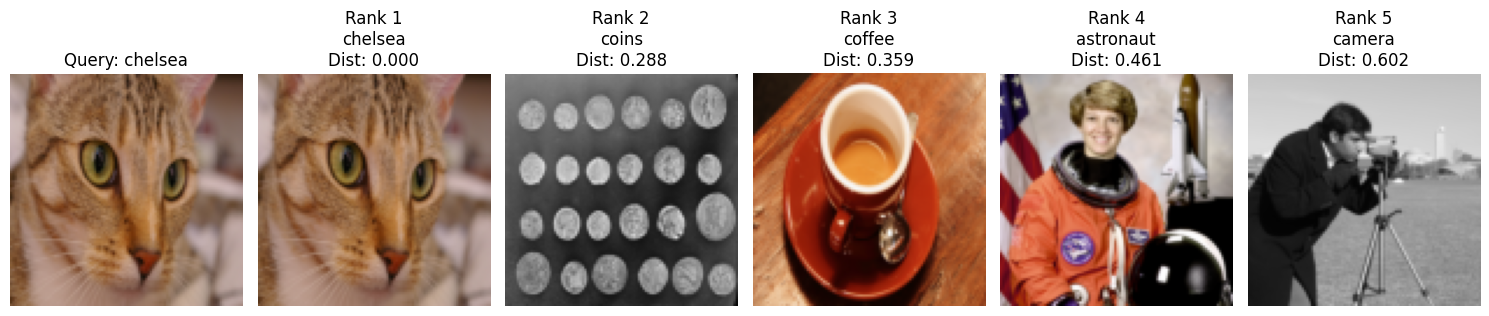

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance


# Fungsi hitung histogram
def calculate_rgb_histogram(image, bins=16):

    # Pastikan input float [0,1] dikonversi ke uint8 [0,255]
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        # Hindari pembagian dengan nol
        hist_combined = hist_combined.astype(float)

    return hist_combined


# Siapkan database citra kecil dan citra query
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_hists = []


print("Memproses database citra...")

for name in image_db_names:

    try:
        img = getattr(data, name)()

        # Jika grayscale, konversi ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran fitur konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        database_images.append(img_resized)

        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} diproses.")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# Pilih satu citra sebagai query
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]

query_hist = database_hists[query_index]


# Hitung jarak antara query dan semua citra di database
# Menggunakan Cosine Distance
distances = []

for i, hist in enumerate(database_hists):

    dist = distance.cosine(query_hist, hist)

    distances.append(dist)


# Urutkan citra berdasarkan jarak
sorted_indices = np.argsort(distances)


# Tampilkan hasil
num_results_to_show = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results_to_show + 1,
    figsize=(15, 3)
)


# Tampilkan query
axes[0].imshow(query_image)

axes[0].set_title(f"Query: {query_image_name}")

axes[0].axis('off')


# Tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")

for i, idx in enumerate(sorted_indices):

    img_rank = i + 1

    ax = axes[img_rank]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {img_rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    ax.axis('off')

    print(
        f"Rank {img_rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )


# Matikan axes yang tidak terpakai
for j in range(num_results_to_show + 1, len(axes)):

    axes[j].axis('off')


plt.tight_layout()

plt.show()

# PENUGASAN

3.	Fitur Berbeda untuk CBIR: Modifikasi Praktikum 5. Alih-alih menggunakan histogram warna, coba gunakan fitur yang lebih sederhana seperti rata-rata warna (mean R, mean G, mean B) sebagai vektor fitur 3 dimensi. Hitung kemiripan menggunakan Jarak Euclidean (L_2) antara vektor fitur rata-rata warna ini. Bandingkan hasil retrievalnya dengan hasil yang menggunakan histogram. Manakah fitur yang lebih baik untuk membedakan citra-citra dalam database kecil tersebut?


Memproses database citra...
astronaut diproses
camera diproses
coffee diproses
coins diproses
chelsea diproses

Hasil Retrieval:
Rank 1: chelsea Distance=0.000
Rank 2: astronaut Distance=0.050
Rank 3: coffee Distance=0.176
Rank 4: camera Distance=0.194
Rank 5: coins Distance=0.211


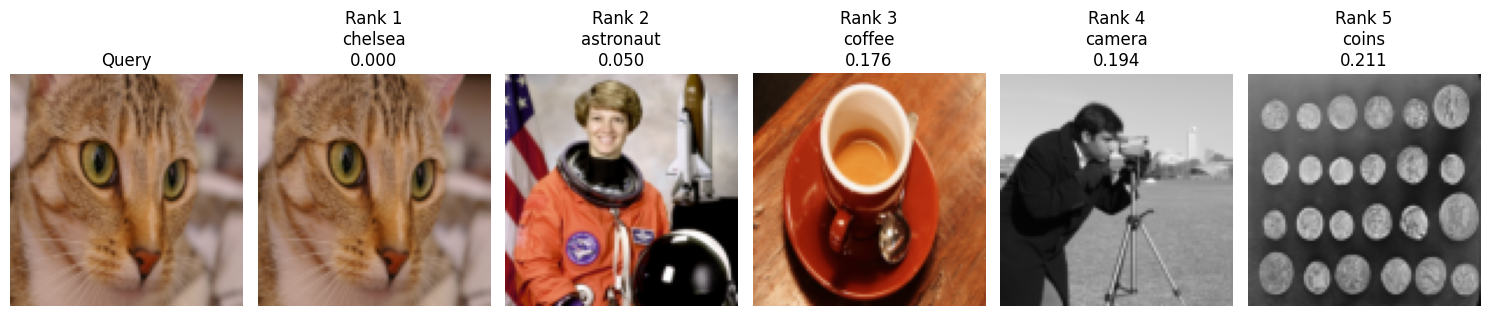

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# Fungsi menghitung rata-rata warna RGB
def calculate_mean_rgb(image):

    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    return np.array([mean_r, mean_g, mean_b])


# Database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_features = []

print("Memproses database citra...")

for name in image_db_names:

    img = getattr(data, name)()

    # Jika grayscale ubah menjadi RGB
    if img.ndim == 2:
        img = color.gray2rgb(img)

    img_resized = transform.resize(
        img,
        (100, 100),
        anti_aliasing=True
    )

    database_images.append(img_resized)

    feature = calculate_mean_rgb(img_resized)

    database_features.append(feature)

    print(f"{name} diproses")


# Query image
query_name = "chelsea"

query_index = image_db_names.index(query_name)

query_image = database_images[query_index]

query_feature = database_features[query_index]


# Hitung jarak Euclidean
distances = []

for feature in database_features:

    dist = distance.euclidean(query_feature, feature)

    distances.append(dist)


# Urutkan hasil retrieval
sorted_indices = np.argsort(distances)


# Visualisasi hasil
fig, axes = plt.subplots(
    1,
    len(database_images) + 1,
    figsize=(15, 3)
)

# Query
axes[0].imshow(query_image)
axes[0].set_title("Query")
axes[0].axis('off')


print("\nHasil Retrieval:")

for i, idx in enumerate(sorted_indices):

    ax = axes[i + 1]

    ax.imshow(database_images[idx])

    ax.set_title(
        f"Rank {i+1}\n"
        f"{image_db_names[idx]}\n"
        f"{distances[idx]:.3f}"
    )

    ax.axis('off')

    print(
        f"Rank {i+1}: "
        f"{image_db_names[idx]} "
        f"Distance={distances[idx]:.3f}"
    )

plt.tight_layout()
plt.show()

4.	Template Matching Invariant: Cari tahu dari dokumentasi skimage.feature.match_template atau sumber lain, apakah metode match_template standar invariant terhadap rotasi atau perubahan skala? Jelaskan. (Petunjuk: Coba rotasi atau ubah ukuran template pada Praktikum 4 dan lihat hasilnya).

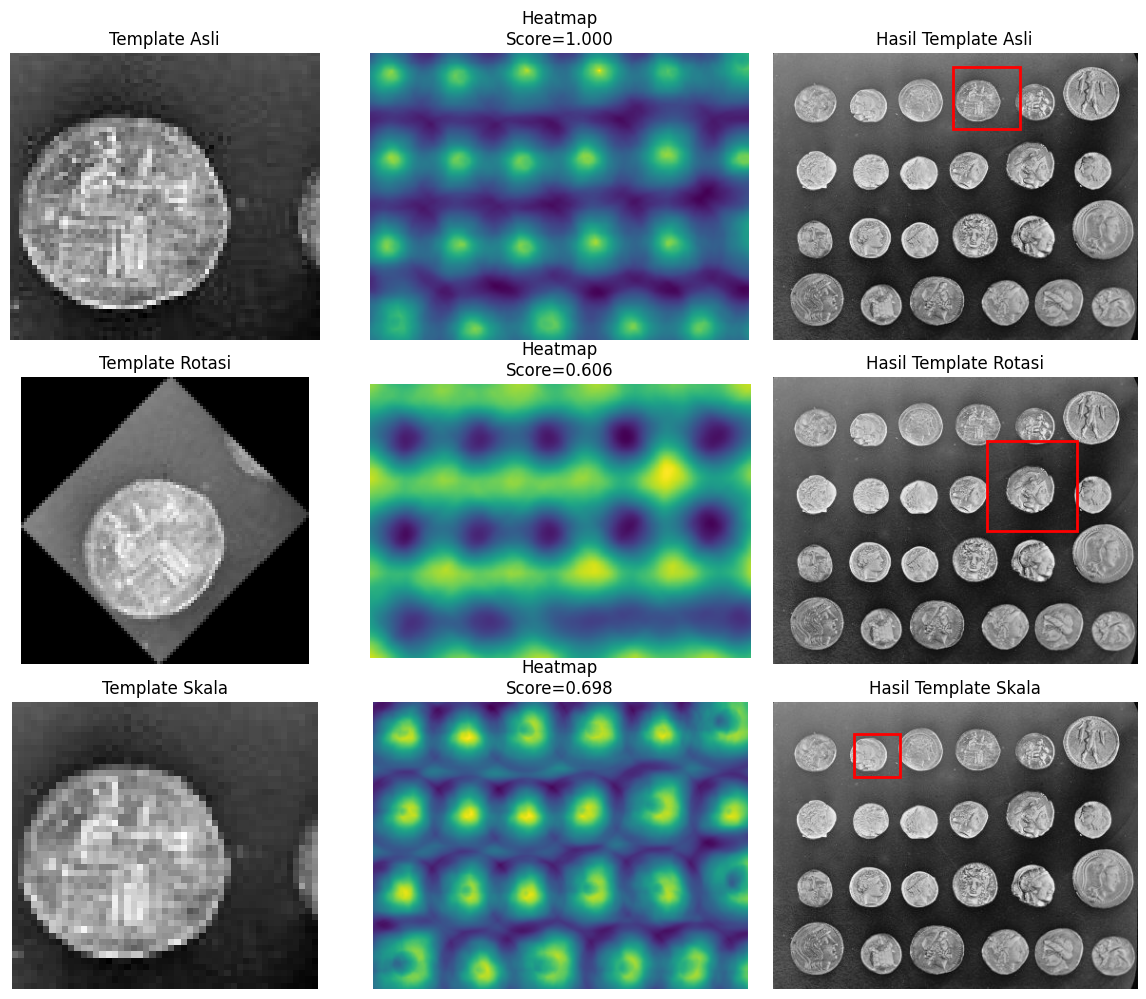

Skor Template Asli   : 1.0000
Skor Template Rotasi : 0.6059
Skor Template Skala  : 0.6979


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale


# Muat citra target
image = data.coins()


# Ambil template asli
template = image[15:80, 190:260]


# Template yang dirotasi
template_rotated = rotate(
    template,
    angle=45,
    resize=True
)


# Template yang diubah skalanya
template_scaled = rescale(
    template,
    scale=0.7,
    anti_aliasing=True
)


# Fungsi template matching
def find_template(img, temp):

    result = match_template(img, temp)

    ij = np.unravel_index(
        np.argmax(result),
        result.shape
    )

    x, y = ij[::-1]

    max_score = np.max(result)

    return result, x, y, max_score


# Matching template asli
result_original, x1, y1, score1 = find_template(
    image,
    template
)

# Matching template rotasi
result_rotated, x2, y2, score2 = find_template(
    image,
    template_rotated
)

# Matching template skala
result_scaled, x3, y3, score3 = find_template(
    image,
    template_scaled
)


# Tampilkan hasil
fig, axes = plt.subplots(3, 3, figsize=(12, 10))


# Template asli
axes[0, 0].imshow(template, cmap='gray')
axes[0, 0].set_title("Template Asli")
axes[0, 0].axis('off')

axes[0, 1].imshow(result_original, cmap='viridis')
axes[0, 1].set_title(f"Heatmap\nScore={score1:.3f}")
axes[0, 1].axis('off')

axes[0, 2].imshow(image, cmap='gray')

rect1 = plt.Rectangle(
    (x1, y1),
    template.shape[1],
    template.shape[0],
    edgecolor='r',
    facecolor='none',
    lw=2
)

axes[0, 2].add_patch(rect1)

axes[0, 2].set_title("Hasil Template Asli")
axes[0, 2].axis('off')


# Template rotasi
axes[1, 0].imshow(template_rotated, cmap='gray')
axes[1, 0].set_title("Template Rotasi")
axes[1, 0].axis('off')

axes[1, 1].imshow(result_rotated, cmap='viridis')
axes[1, 1].set_title(f"Heatmap\nScore={score2:.3f}")
axes[1, 1].axis('off')

axes[1, 2].imshow(image, cmap='gray')

rect2 = plt.Rectangle(
    (x2, y2),
    template_rotated.shape[1],
    template_rotated.shape[0],
    edgecolor='r',
    facecolor='none',
    lw=2
)

axes[1, 2].add_patch(rect2)

axes[1, 2].set_title("Hasil Template Rotasi")
axes[1, 2].axis('off')


# Template skala
axes[2, 0].imshow(template_scaled, cmap='gray')
axes[2, 0].set_title("Template Skala")
axes[2, 0].axis('off')

axes[2, 1].imshow(result_scaled, cmap='viridis')
axes[2, 1].set_title(f"Heatmap\nScore={score3:.3f}")
axes[2, 1].axis('off')

axes[2, 2].imshow(image, cmap='gray')

rect3 = plt.Rectangle(
    (x3, y3),
    template_scaled.shape[1],
    template_scaled.shape[0],
    edgecolor='r',
    facecolor='none',
    lw=2
)

axes[2, 2].add_patch(rect3)

axes[2, 2].set_title("Hasil Template Skala")
axes[2, 2].axis('off')


plt.tight_layout()
plt.show()


# Tampilkan skor matching
print(f"Skor Template Asli   : {score1:.4f}")
print(f"Skor Template Rotasi : {score2:.4f}")
print(f"Skor Template Skala  : {score3:.4f}")